# Service Tickets Analysis - 

In [1]:
import pandas as pd
import numpy as np
import os
from dotenv import load_dotenv
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

load_dotenv()

True

In [ ]:
# Load & Vectorize
dataset_path = os.getenv("DATASET_PATH", "")
df = pd.read_csv(dataset_path)
df = df.sample(n=int(len(df)*0.01), random_state=42).reset_index(drop=True)

vectorizer = TfidfVectorizer(max_features=1000)
X = vectorizer.fit_transform(df['Document'])

print(f"Data: {df.shape[0]} docs | Features: {X.shape[1]}")

Data: 478 docs | Features: 1000


In [3]:
# Cluster
kmeans = KMeans(n_clusters=5, random_state=42, n_init='auto')
df['cluster'] = kmeans.fit_predict(X)

# Metrics
sil = silhouette_score(X, df['cluster'])
db = davies_bouldin_score(X.toarray(), df['cluster'])
ch = calinski_harabasz_score(X.toarray(), df['cluster'])

print(f"Clusters: {df['cluster'].nunique()} | Silhouette: {sil:.4f} | Davies-Bouldin: {db:.4f} | Calinski-Harabasz: {ch:.1f}")
print(f"\nDistribution:\n{df['cluster'].value_counts().sort_index()}")

Clusters: 5 | Silhouette: 0.0223 | Davies-Bouldin: 6.9790 | Calinski-Harabasz: 6.3

Distribution:
cluster
0     87
1    105
2     74
3    193
4     19
Name: count, dtype: int64


In [4]:
# Build EKG
G = nx.Graph()
for idx, row in df.iterrows():
    G.add_edge(f"i{idx}", f"c{row['cluster']}")
    G.add_edge(f"i{idx}", row['Topic_group'])

print(f"EKG: {G.number_of_nodes()} nodes | {G.number_of_edges()} edges")

EKG: 491 nodes | 956 edges


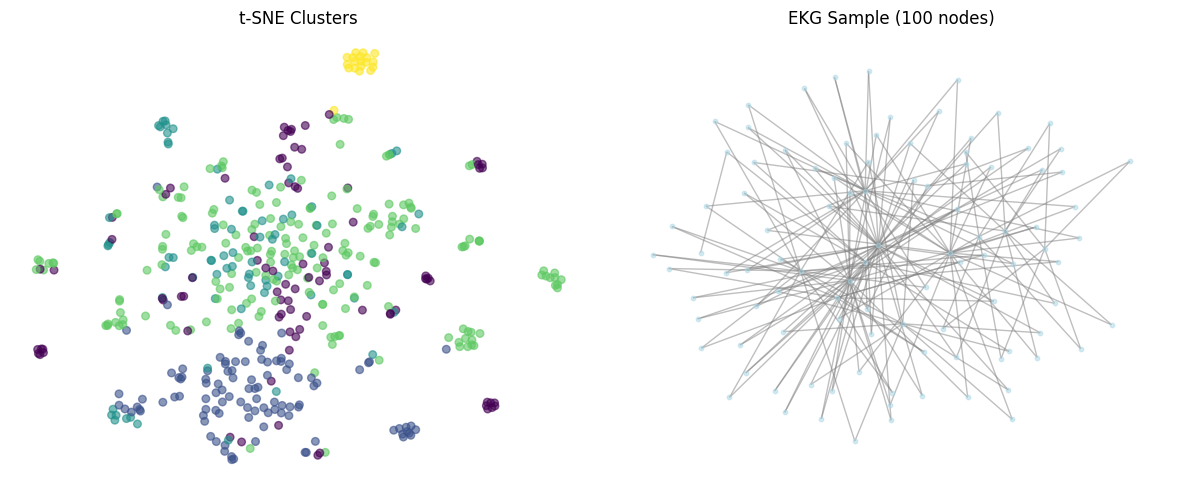

In [5]:
# Visualize
plt.figure(figsize=(12, 5))

# t-SNE
from sklearn.manifold import TSNE
from sklearn.decomposition import TruncatedSVD

X_red = TruncatedSVD(n_components=30, random_state=42).fit_transform(X)
X_2d = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(X_red)

plt.subplot(121)
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=df['cluster'], cmap='viridis', alpha=0.6, s=30)
plt.title('t-SNE Clusters')
plt.axis('off')

# Network sample
plt.subplot(122)
sample = list(G.nodes())[:100]
subG = G.subgraph(sample)
pos = nx.spring_layout(subG, k=0.3, iterations=20, seed=42)
nx.draw(subG, pos, node_size=10, node_color='lightblue', edge_color='gray', alpha=0.5, with_labels=False)
plt.title('EKG Sample (100 nodes)')
plt.axis('off')

plt.tight_layout()
plt.show()